#### Frågor kring OpenAlex

Några frågeställningar som vore bra att utreda i relations till OpenAlex API-gränssnitt (samt datakällan som helhet, för t.ex. en komplett dump)

1) Täckningsgrad av KTHs publikationer? 
	
	 * Hur många publikationer finns för KTH hos OpenAlex? 
        DiVA vs OpenAlex
	 * finns allt i DiVA i OpenAlex? Finns saker kopplade till KTH i Open
         som inte dinns i DiVA? En kontrollista på detta vore intressant att se på (även för DiVA-teamet).
        fokus på det som klassas som peer-review i DiVA
		matcha först och främst på DOI
	    Se på Venn-diagram tex för att få en bild av täckning
		
	* Innehåller OpenAlex allt i Diva?
	
	* Har allt i OpenAlex ett DOI? Eller Crossref ID?
		
2) Duplettkontroll i OpenAlex
	
	* Verkar publ från DiVA (där DiVA betraktas som en "source") även finnas i en version från tidskrifterna?
	Börja med DOI för att se om det finns dupletter där för KTHs publikationer 
	* Gå vidare med titlar för det som inte matchar
	Verkar det finnas versioner av artiklar både från preprint-repon + tidskriftsversion som separata dokument?

3) Datakvalité
	
	* Titta på frekvens NA i olika fält
	* Titta på format på IDn etc (DOI, ISSN). Verkar de ha ett standardiserad, korrekt format?
	* Uppdateringsfrekvens i OpenAlex?
	* Hur städade är vissa fält? Se på tex länder (finns tex på "USA" och "United states" etc) och tidskriftsnamn (titlar vs ISSN)
	* Hur stor frekvens av adressträngarna från KTHs publ har ett unifieret namn/ROR-id?
	* Hur ser klassificeringen av dokumenttyper ut, och hur välstrukturerad verkar den vara?
	* Här välstrukturerad är förlagsinfon? Finns Springer, Elsevier etc hopsamlat eller via många olika namn?
	
4) Jämföra citeringsantal

	* Dvs jämföra antalet citeringar till KTHs dokument, med andra databaser. Detta är kanske något bibliometrigruppen kan göra baserat på en dump som Nazar tar.

#### import library

In [1]:
import requests
from sickle import Sickle
from bs4 import BeautifulSoup
import sys
import os
# import json
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import time
# from colorama import Fore, Back, Style
import datetime
import urllib
import seaborn as sns
%matplotlib inline
import pprint
# import pygwalker as pyg

![](ror-orcid-doi.png)

### 1) Täckningsgrad av KTHs publikationer

#### Extracting Data

In [12]:
# %%timeit
diva_data= pd.read_csv('export.csv')
# diva_data= pd.read_csv('export_2.csv')


# print(df) 

/tmp/ipykernel_130/1021030311.py:2: DtypeWarning: Columns (31,32) have mixed types. Specify dtype option on import or set low_memory=False.
  diva_data= pd.read_csv('export.csv')


In [50]:
df=diva_data
print(df.columns)
df.head()
# df.groupby("Journal").count().sort_values(by=['Year'],ascending=False)[1:10]
# df["Journal"]#.groupby(index).count()

Index(['PID', 'Name', 'Title', 'PublicationType', 'ContentType', 'Language',
       'Journal', 'JournalISSN', 'JournalEISSN', 'Status', 'Volume', 'Issue',
       'HostPublication', 'StartPage', 'EndPage', 'Year', 'Edition', 'Pages',
       'City', 'Publisher', 'Series', 'SeriesISSN', 'SeriesEISSN', 'ISBN',
       'Urls', 'ISRN', 'DOI', 'ISI', 'PMID', 'ScopusId', 'NBN', 'LocalId',
       'ArchiveNumber', 'Keywords', 'Categories', 'ResearchSubjects',
       'Projects', 'Notes', 'Abstract', 'Opponents', 'Supervisors',
       'Examiners', 'Patent', 'ThesisLevel', 'Credits', 'Programme', 'Subject',
       'Uppsok', 'DefencePlace', 'DefenceLanguage', 'DefenceDate',
       'CreatedDate', 'PublicationDate', 'LastUpdated', 'FullTextLink',
       'Funder', 'NumberOfAuthors', 'ExternalCooperation', 'FridaLevel',
       'PartOfThesis', 'PublicationSubtype', 'Conference', 'Term', 'ArticleId',
       'Reviewed', 'FreeFulltext', 'SustainableDevelopment', 'Contributor'],
      dtype='object')


,PID,Name,Title,PublicationType,ContentType,Language,Journal,JournalISSN,JournalEISSN,Status,...,FridaLevel,PartOfThesis,PublicationSubtype,Conference,Term,ArticleId,Reviewed,FreeFulltext,SustainableDevelopment,Contributor
0,1096938,"A Asif, Farazee M [u1z2fliy] [0000-0002-6590-7...",Circular Manufacturing Systems : A development...,"Doktorsavhandling, sammanläggning",Övrigt vetenskapligt,eng,NaN,NaN,NaN,NaN,...,deprecated,NaN,NaN,NaN,NaN,NaN,True,NaN,NaN,NaN
1,589552,"A Asif, Farazee M [u1z2fliy] [0000-0002-6590-7...",Performance analysis of the closed loop supply...,Artikel i tidskrift,Refereegranskat,eng,Journal of Remanufacturing,2210-4690,NaN,published,...,deprecated,urn:nbn:se:kth:diva-207470,editorialMaterial,NaN,NaN,NaN,True,True,NaN,NaN
2,1208838,"A. Hosseini, V.;Karlsson, L.;Örnek, Cem [u1y3d...",Microstructure and functionality of a uniquely...,Artikel i tidskrift,Refereegranskat,eng,Materials Characterization,1044-5803,1873-4189,published,...,deprecated,NaN,NaN,NaN,NaN,NaN,True,NaN,NaN,NaN
3,762425,"A. M. Naiini, Maziar [u1rmo498] (KTH [177], Sk...",Horizontal Slot Waveguides for Silicon Photoni...,"Doktorsavhandling, sammanläggning",Övrigt vetenskapligt,eng,NaN,NaN,NaN,NaN,...,deprecated,NaN,NaN,NaN,NaN,NaN,True,NaN,NaN,NaN
4,1205142,"A Monfared, Behzad [u1d27a52] [0000-0001-9592-...",Magnetic Refrigeration for Near Room-Temperatu...,"Doktorsavhandling, sammanläggning",Övrigt vetenskapligt,eng,NaN,NaN,NaN,NaN,...,deprecated,NaN,NaN,NaN,NaN,NaN,True,NaN,NaN,NaN


In [14]:
## Count NaN Values of DOI
nan_count = df["DOI"].isna().sum()
print("DIVA NaN DOI")
print()
print("Count NaN Values:","\t",nan_count,"\t",f"{nan_count/ len(df) :.2%}") # 100*nan_count/len(df) 

DIVA NaN DOI

Count NaN Values: 	 20462 	 29.30%


In [51]:
Titles_DOIs=df[["Title","DOI"]]
Titles_DOIs=Titles_DOIs.dropna()#[(Titles_DOIs["DOI"]!="NaN")]
DOIs=Titles_DOIs.reset_index(drop=True)
Titles_DOIs=Titles_DOIs.reset_index()
Titles_DOIs


,index,Title,DOI
0,1,Performance analysis of the closed loop supply...,10.1186/2210-4690-2-4
1,2,Microstructure and functionality of a uniquely...,10.1016/j.matchar.2018.03.024
2,5,Multi-tone Signal Optimization for Wireless Po...,10.1109/TWC.2020.2974950
3,6,A Dual-Polarized Multi-Antenna Structure for S...,10.1109/APUSNCURSINRSM.2019.8889079
4,7,ZZ -&gt; l(+)l(-)l '(+)l '(-) cross-section me...,10.1103/PhysRevD.97.032005
...,...,...,...
49374,69792,The involvement of the cerebellum in speech an...,10.4324/9780429321757-17
49375,69794,"Cu adatom charging on Mo supported ScN, MgO an...",10.1039/c5ra18565c
49376,69795,Influence of composition and oxygen-vacancy or...,10.1016/j.scriptamat.2018.08.034
49377,69832,SMaRC Swedish Maritime Robotics Centre : Mid-T...,10.30746/TRITA-SCI-RAP-2020:006


In [7]:
print("\t","Testing randomly 100 records")
print()
doi_not=[]
random_index=random.sample(range(0,len(DOIs)),100)
dois_index=range(0,len(DOIs))

e=0
for i in range(10):
    
    random_index=random.sample(range(0,len(DOIs)),100)
    
    for index in random_index:#random_index:
        try:
            response = requests.get("https://api.openalex.org/works/https://doi.org/" +Titles_DOIs["DOI"][index])
            result = response.json()
        except:
            e = e + 1
            doi_not.append((index,Titles_DOIs["DOI"][index]))
            continue
    
    print(i)#,random_index)
    print(doi_not,"DOI's with error: " +str(e))
    print("-------------")

	 Testing randomly 100 records

0
[(29963, '10.46855/energy-proceedings-10088')] DOI's with error: 1
-------------
1
[(29963, '10.46855/energy-proceedings-10088'), (41514, '10.13140/RG.2.2.21530.16323'), (44156, '10.1063/1.3456319')] DOI's with error: 3
-------------
2
[(29963, '10.46855/energy-proceedings-10088'), (41514, '10.13140/RG.2.2.21530.16323'), (44156, '10.1063/1.3456319')] DOI's with error: 3
-------------
3
[(29963, '10.46855/energy-proceedings-10088'), (41514, '10.13140/RG.2.2.21530.16323'), (44156, '10.1063/1.3456319')] DOI's with error: 3
-------------
4
[(29963, '10.46855/energy-proceedings-10088'), (41514, '10.13140/RG.2.2.21530.16323'), (44156, '10.1063/1.3456319')] DOI's with error: 3
-------------
5
[(29963, '10.46855/energy-proceedings-10088'), (41514, '10.13140/RG.2.2.21530.16323'), (44156, '10.1063/1.3456319')] DOI's with error: 3
-------------
6
[(29963, '10.46855/energy-proceedings-10088'), (41514, '10.13140/RG.2.2.21530.16323'), (44156, '10.1063/1.3456319'), (

In [131]:
## or
# https://api.openalex.org/works?per-page=200&page=8&filter=institutions.ror:https://ror.org/026vcq606,is_paratext:false,type:journal-article,from_publication_date:2010-01-01,to_publication_date:2011-01-01
# url="https://api.openalex.org/works?filter=institutions.ror:https://ror.org/026vcq606,is_paratext:false,type:journal-article,from_publication_date:2010-01-01,to_publication_date:2015-01-01"
# url="https://api.openalex.org/works?filter=institutions.ror:https://ror.org/026vcq606,is_paratext:false,type:journal-article,from_publication_date:2015-01-02,to_publication_date:2018-01-01"
# url="https://api.openalex.org/works?filter=institutions.ror:https://ror.org/026vcq606,is_paratext:false,type:journal-article,from_publication_date:2018-01-02,to_publication_date:2021-01-01"
# url="https://api.openalex.org/works?filter=institutions.ror:https://ror.org/026vcq606,is_paratext:false,type:journal-article,from_publication_date:2010-01-01"#,to_publication_date:2023-01-01"

# response = requests.get(url)
# r=response.json()

In [144]:
# start="2017-01-01"
# end="2011-01-01"

# url=f"https://api.openalex.org/works?filter=institutions.ror:https://ror.org/026vcq606,is_paratext:false,type:journal-article,from_publication_date:{start},to_publication_date:{end}"
# response = requests.get(url)
# r=response.json()


In [ ]:
#url="https://api.openalex.org/works?per-page=200&page=11&filter=institutions.id:I86987016,type:journal-article,from_publication_date:2000-01-01,to_publication_date:2022-12-31"

In [30]:

start="2021-01-02"
end="2023-03-02"

## is_paratext:false,type:journal-article
# url=f"https://api.openalex.org/works?filter=institutions.ror:https://ror.org/026vcq606,is_paratext:false,type:journal-article,from_publication_date:{start},to_publication_date:{end}"

## is_paratext:false
# url=f"https://api.openalex.org/works?filter=institutions.ror:https://ror.org/026vcq606,is_paratext:false,from_publication_date:{start},to_publication_date:{end}"

## all
url=f"https://api.openalex.org/works?filter=institutions.ror:https://ror.org/026vcq606,from_publication_date:{start},to_publication_date:{end}"


response = requests.get(url)
r=response.json()
print(r["meta"])
titles=[]
works=[]
First_authors=[]
institutions=[]
is_OA_list=[]
color_OA_list=[]
host_name_list=[]
publishers_list=[]

year=[]
journal=[]
Work_type=[]
journal_issn=[]
# for page in range(51,r["meta"]["count"]//200+2):

# # url with a placeholder for cursor
# example_url_with_cursor = 'https://api.openalex.org/works?filter=author.id:A1969205032&cursor={}'

cursor = '*'
# loop through pages
for page in range(1,r["meta"]["count"]//200+2):
#while cursor:

    ### is_paratext:false,type:journal-article
    # url=f"https://api.openalex.org/works?per-page=200&page={page}&filter=institutions.id:I86987016,type:journal-article,from_publication_date:{start},to_publication_date:{end}"
    
    ### ## is_paratext:false
    # url=f"https://api.openalex.org/works?per-page=200&page={page}&filter=institutions.id:I86987016,from_publication_date:{start},to_publication_date:{end}"
    
    ### ALL
    url=f"https://api.openalex.org/works?per-page=200&page={page}&filter=institutions.id:I86987016,from_publication_date:{start},to_publication_date:{end}"
    

    response = requests.get(url)
    r=response.json()

    for i  in range(len(r["results"])):
        work=r["results"][i]["doi"]
        title=r["results"][i]["title"]
        publication_year=r["results"][i]["publication_year"]
        
        First_author=r["results"][i]["authorships"][0]["author"]["display_name"]
        if r["results"][i]["authorships"][0]["institutions"]!=[]:
            institution=r["results"][i]["authorships"][0]["institutions"][0]["display_name"]
        else:
                institution="--"
        is_OA=r["results"][i]["open_access"]["is_oa"]
        color_OA=r["results"][i]["open_access"]["oa_status"]
        host_name=r["results"][i]["host_venue"]["display_name"]
        publisher_name=r["results"][i]["host_venue"]["publisher"]
        WorkType=r["results"][i]["type"]
        journalISSN=r["results"][i]["host_venue"]["issn"]
    
        ## appending results
        titles.append(title)
        works.append(work)
        First_authors.append(First_author)
        institutions.append(institution)
        is_OA_list.append(is_OA)
        color_OA_list.append(color_OA)
        host_name_list.append(host_name)
        publishers_list.append(publisher_name)
        year.append(publication_year)
        Work_type.append(WorkType)
        journal_issn.append(journalISSN)
    


    
data_frame=pd.DataFrame(
    {"title":titles,
     "work":works,
     "First_author":First_authors,
     "institution":institutions,
     "is OA":is_OA_list,
     "color_OA":color_OA_list,
     "host_name":host_name_list,
     "publisher":publishers_list,
     "publication_year":year,
     "type": Work_type,
     "issn":journal_issn
     
     
    }
)

# data_frame.to_csv("works-OA_2021-2023.csv",index=False,header=True)


{'count': 7357, 'db_response_time_ms': 78, 'page': 1, 'per_page': 25}


In [31]:
## appending 
# data_frame.to_csv("works-OA_2010-2023_03_02.csv", mode="a", index=False)#,header=True)

In [5]:
# print(page)
# print(response.headers)
# print()
# print(response.text)

data_frame=pd.DataFrame(
    {"title":titles,
     "work":works,
     "First_author":First_authors,
     "institution":institutions,
     "is OA":is_OA_list,
     "color_OA":color_OA_list,
     "host_name":host_name_list,
     "publisher":publishers_list,
     "publication_year":year,
     "type": Work_type,
     "issn":journal_issn
     
     
    }
)

# data_frame.tail(20)
# len(response.json()["results"])
# data_frame,page
data_frame

,title,work,First_author,institution,is OA,color_OA,host_name,publisher,publication_year,type,issn
0,Dye-Sensitized Solar Cells,https://doi.org/10.1021/cr900356p,Anders Hagfeldt,Royal Institute of Technology,False,closed,Chemical Reviews,American Chemical Society,2010,journal-article,"[1520-6890, 0009-2665]"
1,GROMACS 4.5: a high-throughput and highly para...,https://doi.org/10.1093/bioinformatics/btt055,Sander Pronk,Science for Life Laboratory,True,bronze,Computer applications in the biosciences,Oxford University Press,2013,journal-article,"[1460-2059, 0266-7061]"
2,CNN Features Off-the-Shelf: An Astounding Base...,https://doi.org/10.1109/cvprw.2014.131,Ali Sharif Razavian,Royal Institute of Technology,True,green,Computer Vision and Pattern Recognition,None,2014,proceedings-article,None
3,Analysis of the Human Tissue-specific Expressi...,https://doi.org/10.1074/mcp.m113.035600,Linn Fagerberg,Royal Institute of Technology,True,hybrid,Molecular & Cellular Proteomics,American Society for Biochemistry and Molecula...,2014,journal-article,"[1535-9476, 1535-9484]"
4,Towards a knowledge-based Human Protein Atlas,https://doi.org/10.1038/nbt1210-1248,Mathias Uhlén,Royal Institute of Technology,False,closed,Nature Biotechnology,Nature Portfolio,2010,journal-article,"[1546-1696, 1087-0156]"
...,...,...,...,...,...,...,...,...,...,...,...
9995,Simulation on the Flow and Heat Transfer Chara...,https://doi.org/10.1115/icnmm2012-73108,Qingming Liu,Royal Institute of Technology,False,closed,ASME 2012 10th International Conference on Nan...,None,2012,proceedings-article,None
9996,Sustainable use of crushed autoclaved aerated ...,None,Gunno Renman,Royal Institute of Technology,False,None,8th International conference on sustainable ma...,None,2012,None,None
9997,Attainable user throughput by dense Wi-Fi depl...,https://doi.org/10.1109/pimrc.2013.6666739,Du Ho Kang,Royal Institute of Technology,False,closed,"Personal, Indoor and Mobile Radio Communications",None,2013,proceedings-article,None
9998,An adaptive strategy for the bivariate solutio...,https://doi.org/10.1002/nme.4777,Romain Rumpler,Creo Dynamics AB Westmansgatan 37 58216 Linköp...,False,closed,International Journal for Numerical Methods in...,Wiley-Blackwell,2014,journal-article,"[0029-5981, 1097-0207]"


In [33]:
# save to file
# data_frame.to_csv("publisher-OA_2021-2023.csv",index=False)


In [34]:
## appending 
# data_frame.to_csv("publisher-OA_2010-2023_03_16.csv", mode="a", index=False,header=False)

#### KTH publictions masterfile

In [8]:
# df1=openAlex_data[openAlex_data["work"].dropna()]
# df1
## reading masterfile xlsx
# kth_master= pd.read_excel('KTH_publications_masterfile.xlsx')#,sheet_name="reprint_KTH_prelim")

In [23]:
## sving to .sv
# kth_master.to_csv("KTH_publications_masterfile.csv",index=False)# eader=False)

In [2]:
kth_master_file= pd.read_csv('KTH_publications_masterfile.csv')

In [4]:
## https://docs.kanaries.net/pygwalker
# gwalker = pyg.walk(kth_master_file)

In [290]:
print(kth_master_file.columns)
kth_master_file.head()

Index(['analysis_id', 'Unit_code', 'Unit_Name', 'Unit_Fraction', 'is_kth',
       'PID', 'Doc_id', 'WebofScience_ID', 'Bibliographic_Information',
       'Publication_Year', 'Publication_Type_DiVA', 'Publication_Type_WoS',
       'WoS_Journal', 'jcf', 'Jtop20', 'Citations', 'Citations_3yr', 'cf',
       'Ptop1', 'Ptop10', 'Ptop25', 'w_subj', 'swe_nuniv', 'int',
       'Unit_Fraction_adj', 'level', 'ScopusID', 'scop_doctype',
       'scop_sourcetype', 'scop_journal', 'scop_corp', 'scop_int',
       'scop_cscxo', 'scop_fwci_x', 'scop_Ptop1', 'scop_Ptop10', 'scop_Ptop25',
       'scop_snip', 'scop_Jtop20', 'is_oa', 'oa_status', 'n_authors', 'Ptop5',
       'Cf_log', 'DOI'],
      dtype='object')


,analysis_id,Unit_code,Unit_Name,Unit_Fraction,is_kth,PID,Doc_id,WebofScience_ID,Bibliographic_Information,Publication_Year,...,scop_Ptop10,scop_Ptop25,scop_snip,scop_Jtop20,is_oa,oa_status,n_authors,Ptop5,Cf_log,DOI
0,0,KTH,KTH Royal Institute of Technology,0.125000,1,1046963,51845840.0,3.855983e+11,"Zhang, W.;, Cai, Y.;, Wang, Baoyuan, Deng, ...",2016,...,0.0,0.0,1.297,1.0,False,closed,8,0.0,0.950488,10.1016/j.ijhydene.2016.01.127
1,0,KTH,KTH Royal Institute of Technology,1.000000,1,1046987,89946081.0,3.892848e+11,"Mattsson, Lars (2016) ""Modelling dust processi...",2016,...,0.0,0.0,0.913,0.0,True,green,1,0.0,1.214454,10.1016/j.pss.2016.05.002
2,0,KTH,KTH Royal Institute of Technology,0.666667,1,1047057,NaN,NaN,"Manjate, Juvencio, Hidell, Markus, SjÃ¶din, ...",2015,...,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN,NaN,NaN
3,0,KTH,KTH Royal Institute of Technology,0.181818,1,1047101,52143373.0,3.849506e+11,"Claesson, A.;, Fredman, D.;, Svensson, L.;, ...",2016,...,1.0,1.0,1.067,0.0,True,gold,11,1.0,2.712819,10.1186/s13049-016-0313-5
4,0,KTH,KTH Royal Institute of Technology,1.000000,1,1670001,NaN,NaN,"El-Bealy, Mostafa Omar (2016) ""Initial Develop...",2016,...,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,10.1002/9781119274780.ch110


In [300]:
kth_master=kth_master_file[['Publication_Year', 'Publication_Type_DiVA', 'Publication_Type_WoS',
       'WoS_Journal',"is_oa","oa_status","DOI"]]

In [301]:
## Count NaN Values of DOI
nan_DOI= kth_master["DOI"].isna().sum()
print("\t\t","Total","\t","NaN DOI")
print("DIVA:","\t\t",len(kth_master),"\t",nan_DOI,"\t\t",f"{nan_DOI/ len(kth_master) :.2%}") 

		 Total 	 NaN DOI
DIVA: 		 67188 	 18349 		 27.31%


In [302]:
plt.style.use('Solarize_Light2')
pd.DataFrame(kth_master.isna().sum())#.plot.barh(title="KTH publications master",xlabel="NaN values count",ylabel="Fields",figsize=(8,6),fontsize=10,legend=False)

,0
Publication_Year,0
Publication_Type_DiVA,0
Publication_Type_WoS,23645
WoS_Journal,23645
is_oa,20314
oa_status,20314
DOI,18349


<AxesSubplot: title={'center': 'KTH publications master'}, xlabel='count', ylabel='journal'>

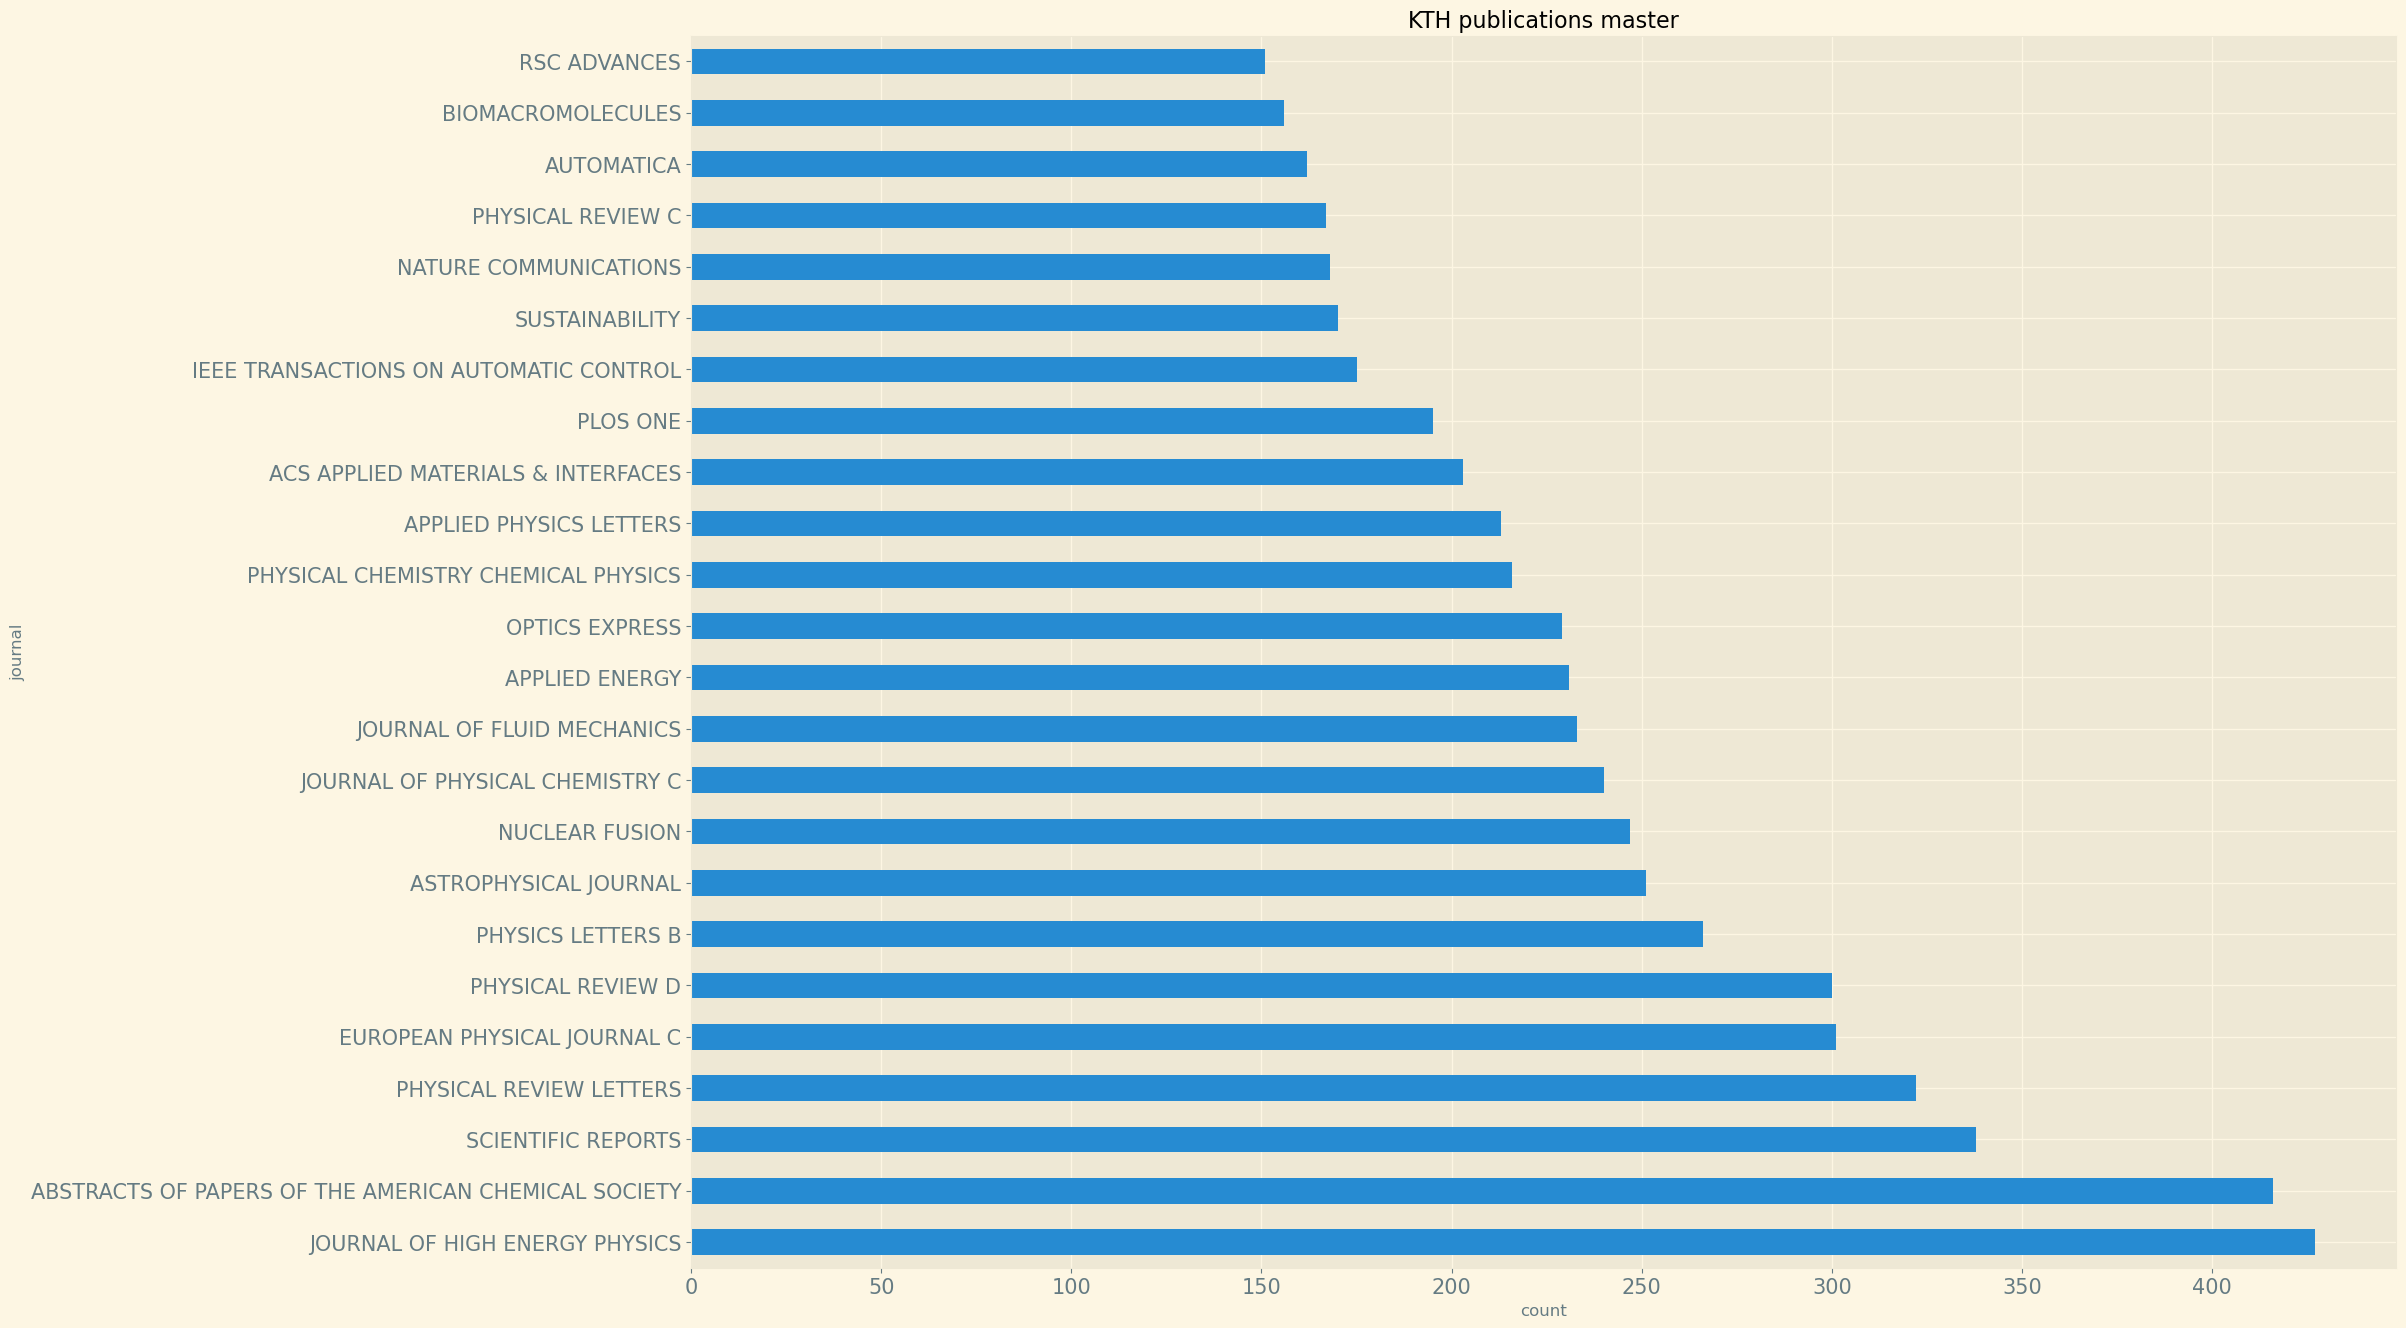

In [303]:
plt.style.use('Solarize_Light2')
kth_master[["WoS_Journal","Publication_Year"]].groupby("WoS_Journal").count().sort_values(by=["Publication_Year"],ascending=False)[1:25].plot.barh(title="KTH publications master",xlabel="count",ylabel="journal",figsize=(22,16),fontsize=15,legend=False)

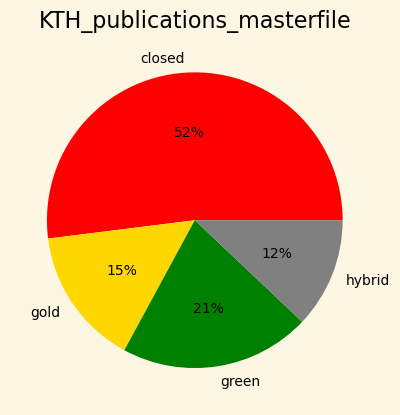

oa_status
closed    24366
gold       7085
green      9769
hybrid     5654
dtype: int64

Total: 46874


In [309]:
colors={
    "bronze":"peru",
    "closed":"red",
    "gold":"gold",
    "green":"green",     
     "hybrid":"grey"
}


data=kth_master.groupby(by=["oa_status"]).count()


data=data["is_oa"]

##create pie chart
plt.pie(data,
        labels = data.index,
        autopct='%.0f%%',
        colors=[colors[index] for index in data.index]
       )
plt.title("KTH_publications_masterfile")
plt.show()
data.index
data
display(kth_master.groupby(by=["oa_status"]).size())
print("Total:",data.sum())

<table>
<thead>
<tr><th>closed</th><th>gold</th><th>green</th><th>hybrid</th><th>total</th></tr>
</thead>
<tbody>
<tr><td>24366</td><td>7085</td><td>9769</td><td>5654</td><td>46874</td></tr>
</tbody>
</table>




#### DOIs from diva to alex

In [2]:
diva_data= pd.read_csv('export.csv')
df0=diva_data
dois=df0["DOI"].dropna()
dois

/tmp/ipykernel_101/4031001489.py:1: DtypeWarning: Columns (31,32) have mixed types. Specify dtype option on import or set low_memory=False.
  diva_data= pd.read_csv('export.csv')


1                      10.1186/2210-4690-2-4
2              10.1016/j.matchar.2018.03.024
5                   10.1109/TWC.2020.2974950
6        10.1109/APUSNCURSINRSM.2019.8889079
7                 10.1103/PhysRevD.97.032005
                        ...                 
69792               10.4324/9780429321757-17
69794                     10.1039/c5ra18565c
69795       10.1016/j.scriptamat.2018.08.034
69832        10.30746/TRITA-SCI-RAP-2020:006
69837              10.1007/978-3-030-50555-4
Name: DOI, Length: 49379, dtype: object

In [16]:
e=0
titles=[]
works=[]
First_authors=[]
institutions=[]
is_OA_list=[]
color_OA_list=[]
host_name_list=[]
publishers_list=[]
year=[]
journal=[]
Work_type=[]
journal_issn=[]
pipe_separated_dois = "|".join(dois[0:50])
# r = requests.get(f"https://api.openalex.org/works?filter=doi:{pipe_separated_dois}&per-page=50&mailto=support@openalex.org")
# works = r.json()["results"]
# pipe_separated_dois,len(dois)//50
# # pipe_separated_dois = "|".join(dois[i*50:(i+1)*50]
# [i*50:(i+1)*50]





# response = requests.get(f"https://api.openalex.org/works?filter=doi:{pipe_separated_dois}&per-page=50")
# r= response.json()

for i in range(len(r["results"])):
    titles.append(r["results"][i]["title"])
    works.append(r["results"][i]["doi"])
    is_OA_list.append(r["results"][i]["open_access"]["is_oa"])
    color_OA_list.append(r["results"][i]["open_access"]["oa_status"])
    host_name_list.append(r["results"][i]["host_venue"]["display_name"])
    publishers_list.append(r["results"][i]["host_venue"]["publisher"])
    journal_issn.append(r["results"][i]["host_venue"]['issn'])
    year.append(r["results"][i]["publication_date"])
    Work_type.append(r["results"][i]["type"])

data_frame=pd.DataFrame(
            {"title":titles,
             "work":works,
             "type": Work_type,
             "is OA":is_OA_list,
             "color_OA":color_OA_list,
             "host_name":host_name_list,
             "publisher":publishers_list,
             "issn":journal_issn,
             "publication_year":year
            }
        )
data_frame

,title,work,type,is OA,color_OA,host_name,publisher,issn,publication_year
0,Combination of Searches for Invisible Higgs Bo...,https://doi.org/10.1103/physrevlett.122.231801,journal-article,True,hybrid,Physical Review Letters,American Physical Society,"[1079-7114, 0031-9007, 1092-0145]",2019-06-13
1,Combination of the Searches for Pair-Produced ...,https://doi.org/10.1103/physrevlett.121.211801,journal-article,True,hybrid,Physical Review Letters,American Physical Society,"[1079-7114, 0031-9007, 1092-0145]",2018-11-20
2,Search for scalar leptoquarks inppcollisions a...,https://doi.org/10.1088/1367-2630/18/9/093016,journal-article,True,gold,New Journal of Physics,IOP Publishing,[1367-2630],2016-09-07
3,Cross-section measurements of the Higgs boson ...,https://doi.org/10.1103/physrevd.99.072001,journal-article,True,hybrid,Physical review,American Physical Society,"[2470-0037, 2470-0010, 2470-0029]",2019-04-10
4,Measurements of gluon–gluon fusion and vector-...,https://doi.org/10.1016/j.physletb.2018.11.064,journal-article,True,gold,Physics Letters B,Elsevier BV,"[0370-2693, 1873-2445]",2019-02-10
5,A search for pair-produced resonances in four-...,https://doi.org/10.1140/epjc/s10052-018-5693-4,journal-article,True,gold,European Physical Journal C,Springer Science+Business Media,"[1434-6044, 1434-6052]",2018-03-22
6,Observation of Electroweak Production of a Sam...,https://doi.org/10.1103/physrevlett.123.161801,journal-article,True,hybrid,Physical Review Letters,American Physical Society,"[1079-7114, 0031-9007, 1092-0145]",2019-10-15
7,Search for metastable heavy charged particles ...,https://doi.org/10.1103/physrevd.93.112015,journal-article,True,hybrid,Physical review,American Physical Society,"[2470-0037, 2470-0010, 2470-0029]",2016-06-28
8,Search for heavy long-lived charged R-hadrons ...,https://doi.org/10.1016/j.physletb.2016.07.042,journal-article,True,gold,Physics Letters B,Elsevier BV,"[0370-2693, 1873-2445]",2016-09-10
9,Performance analysis of the closed loop supply...,https://doi.org/10.1186/2210-4690-2-4,journal-article,True,hybrid,Journal of remanufacturing,Springer Science+Business Media,"[2210-4690, 2210-464X]",2012-11-06


In [73]:
# e=0
# titles=[]
# works=[]
# First_authors=[]
# institutions=[]
# is_OA_list=[]
# color_OA_list=[]
# host_name_list=[]
# publishers_list=[]
# year=[]
# journal=[]
# Work_type=[]
# journal_issn=[]

# for i in range(len(dois)//50 +1):
#     try:
#         pipe_separated_dois = "|".join(dois[i*50:(i+1)*50])
#         response = requests.get(f"https://api.openalex.org/works?filter=doi:{pipe_separated_dois}&per-page=50")
#         r= response.json()
#         for i in range(len(r["results"])):
#             titles.append(r["results"][i]["title"])
#             works.append(r["results"][i]["doi"])
#             is_OA_list.append(r["results"][i]["open_access"]["is_oa"])
#             color_OA_list.append(r["results"][i]["open_access"]["oa_status"])
#             host_name_list.append(r["results"][i]["host_venue"]["display_name"])
#             publishers_list.append(r["results"][i]["host_venue"]["publisher"])
#             journal_issn.append(r["results"][i]["host_venue"]['issn'])
#             year.append(r["results"][i]["publication_date"])
#             Work_type.append(r["results"][i]["type"])
    
#     except:
#         e = e + 1
#         # doi_not_openalex[f"{k}"]=doi
#         continue



# data_frame=pd.DataFrame(
#             {"title":titles,
#              "work":works,
#              "type": Work_type,
#              "is OA":is_OA_list,
#              "color_OA":color_OA_list,
#              "host_name":host_name_list,
#              "publisher":publishers_list,
#              "issn":journal_issn,
#              "publication_year":year
#             }
#         )

# data_frame.to_csv("dois_from_diva_in_alex1.csv",index=False)

In [76]:
# data_frame,data_frame.to_csv("dois_from_diva_in_alex1.csv",index=False)

(                                                   title  \
 0      Combination of Searches for Invisible Higgs Bo...   
 1      Combination of the Searches for Pair-Produced ...   
 2      Search for scalar leptoquarks inppcollisions a...   
 3      Cross-section measurements of the Higgs boson ...   
 4      Measurements of gluon–gluon fusion and vector-...   
 ...                                                  ...   
 48862  The Involvement of the Cerebellum in Speech an...   
 48863                             Technical Universities   
 48864  Cosmological effects on the observed flux and ...   
 48865  Platoon-actuated variable area mainstream traf...   
 48866  Front-tracking transition system model for tra...   
 
                                                  work             type  is OA  \
 0      https://doi.org/10.1103/physrevlett.122.231801  journal-article   True   
 1      https://doi.org/10.1103/physrevlett.121.211801  journal-article   True   
 2       https://doi

In [ ]:
# dois=df0["DOI"].dropna()
# titles=[]
# works=[]
# First_authors=[]
# institutions=[]
# is_OA_list=[]
# color_OA_list=[]
# host_name_list=[]
# publishers_list=[]
# year=[]
# journal=[]
# Work_type=[]
# journal_issn=[]
# e = 0
# k=0
# doi_not_openalex={}
# start = time.time()
# for doi in dois:
    
#     try:
#         response = requests.get("https://api.openalex.org/works/https://doi.org/" +doi)
#         r= response.json()
        
#         work=r["doi"]
#         title=r["title"]
#         publication_year=r["publication_year"]
#         is_OA=r["open_access"]["is_oa"]
#         color_OA=r["open_access"]["oa_status"]
#         host_name=r["host_venue"]["display_name"]
#         publisher_name=r["host_venue"]["publisher"]
#         WorkType=r["type"]
    
# #       ## appending results
#         titles.append(title)
#         works.append(work)
#         is_OA_list.append(is_OA)
#         color_OA_list.append(color_OA)
#         host_name_list.append(host_name)
#         publishers_list.append(publisher_name)
#         year.append(publication_year)
#         Work_type.append(WorkType)
        
#     except:
#         e = e + 1
#         doi_not_openalex[f"{k}"]=doi
#         continue
#     if k%100==0:
#         print(k)
#     k+=1
#     if k%5000==0:
#         d0=pd.DataFrame(
#             {"title":titles,
#              "work":works,
#              "is OA":is_OA_list,
#              "color_OA":color_OA_list,
#              "host_name":host_name_list,
#              "publisher":publishers_list,
#              "publication_year":year,
#              "type": Work_type
#             }
#         )
#         filename="dois_from_diva_in_alex_0_"+f"{k}"+".csv"
#         d0.to_csv(filename,index=False)


    
# end= time.time()
# print("Total time:",(end - start)/60,"minutes") # time in seconds
# print("DOI's with error: " + str(e))
# print("DOI's with error: " , doi_not_openalex)
# # r,response.url


# data_frame=pd.DataFrame(
#     {"title":titles,
#      "work":works,
#      "is OA":is_OA_list,
#      "color_OA":color_OA_list,
#      "host_name":host_name_list,
#      "publisher":publishers_list,
#      "publication_year":year,
#      "type": Work_type,
#         }
# )

# d=pd.DataFrame(doi_not_openalex)
# # data_frame.to_csv("dois_from_diva_in_alex1.csv",index=False)
# # # doi_not_openalex.to_csv("dois_from_diva_not_in_alex.csv",index=False)

0
100


In [23]:
diva_data= pd.read_csv('export.csv')
openAlex_data= pd.read_csv('works-OA_2010-2023_03_02.csv')
dois_from_diva_in_alex= pd.read_csv('dois_from_diva_in_alex1.csv')

/tmp/ipykernel_101/1513424320.py:1: DtypeWarning: Columns (31,32) have mixed types. Specify dtype option on import or set low_memory=False.
  diva_data= pd.read_csv('export.csv')


In [24]:
dois_from_diva_in_alex

,title,work,type,is OA,color_OA,host_name,publisher,issn,publication_year
0,Combination of Searches for Invisible Higgs Bo...,https://doi.org/10.1103/physrevlett.122.231801,journal-article,True,hybrid,Physical Review Letters,American Physical Society,"['1079-7114', '0031-9007', '1092-0145']",2019-06-13
1,Combination of the Searches for Pair-Produced ...,https://doi.org/10.1103/physrevlett.121.211801,journal-article,True,hybrid,Physical Review Letters,American Physical Society,"['1079-7114', '0031-9007', '1092-0145']",2018-11-20
2,Search for scalar leptoquarks inppcollisions a...,https://doi.org/10.1088/1367-2630/18/9/093016,journal-article,True,gold,New Journal of Physics,IOP Publishing,['1367-2630'],2016-09-07
3,Cross-section measurements of the Higgs boson ...,https://doi.org/10.1103/physrevd.99.072001,journal-article,True,hybrid,Physical review,American Physical Society,"['2470-0037', '2470-0010', '2470-0029']",2019-04-10
4,Measurements of gluon–gluon fusion and vector-...,https://doi.org/10.1016/j.physletb.2018.11.064,journal-article,True,gold,Physics Letters B,Elsevier BV,"['0370-2693', '1873-2445']",2019-02-10
...,...,...,...,...,...,...,...,...,...
48862,The Involvement of the Cerebellum in Speech an...,https://doi.org/10.4324/9780429321757-17,book-chapter,False,closed,Routledge eBooks,Informa,NaN,2019-10-21
48863,Technical Universities,https://doi.org/10.1007/978-3-030-50555-4,book,True,hybrid,Higher education dynamics,Springer Nature (Netherlands),"['1571-0378', '2215-1923']",2020-01-01
48864,Cosmological effects on the observed flux and ...,https://doi.org/10.1017/s1743921312013464,journal-article,True,bronze,Proceedings of the International Astronomical ...,Cambridge University Press,"['1743-9221', '1743-9213']",2011-04-01
48865,Platoon-actuated variable area mainstream traf...,https://doi.org/10.1016/j.ejcon.2022.100687,journal-article,True,hybrid,European Journal of Control,Elsevier BV,"['0947-3580', '1435-5671']",2022-06-01


In [20]:
# df00=dois_from_diva_in_alex
# print("Diva all with NaN:",len(df0))
# print("Diva Without NaN:",len(df0.isna().sum()))
# print("all with NaN:",len(df00))
# dois00=df00["work"].dropna()
# print("Without  NaN:",len(dois00))

# print("With no doublicates:",len((dois00.drop_duplicates())))
# dois00.head(10)

In [56]:
# diva_data

DOIs from diva and are in openAlex types:



/tmp/ipykernel_101/1597142950.py:8: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  plt.subplot(3,1,1)


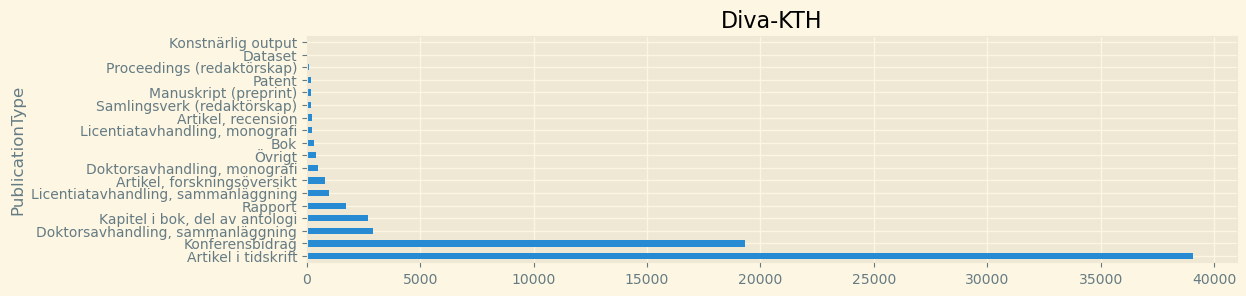

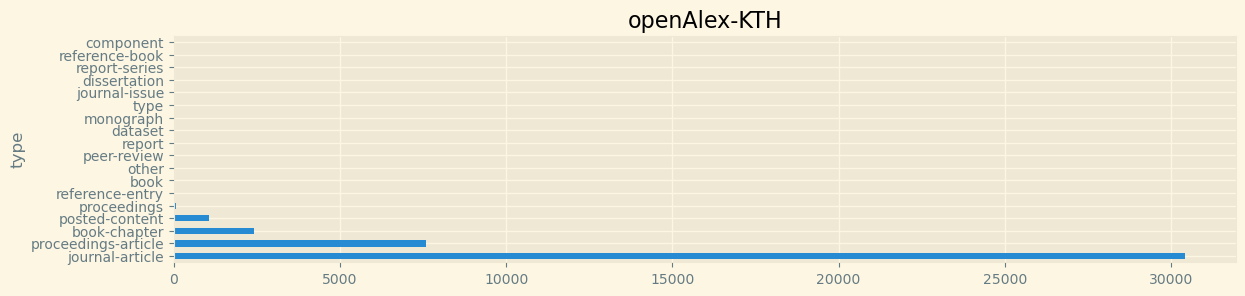

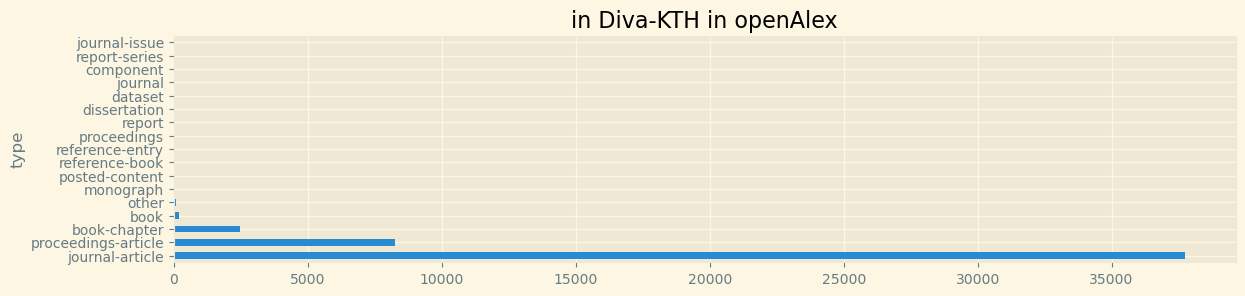

In [25]:
plt.style.use('Solarize_Light2')
print("DOIs from diva and are in openAlex types:")
print()
openAlex_data.groupby("type").count().sort_values(by=["work"],ascending=False)["work"].plot.barh()
diva_data.groupby("PublicationType").count().sort_values(by=["Title"],ascending=False)["Title"].plot.barh()
dois_from_diva_in_alex.groupby("type").count().sort_values(by=["work"],ascending=False)["work"].plot.barh()

plt.subplot(3,1,1)
# print(diva_data.groupby("PublicationType").count().sort_values(by=["Title"],ascending=False)["Title"])
diva_data.groupby("PublicationType").count().sort_values(by=["Title"],ascending=False)["Title"].plot.barh(title="Diva-KTH",figsize=(12,10),fontsize=10)
plt.show()
plt.subplot(3,1,2)
# print(dois_from_diva_in_alex.groupby("type").count().sort_values(by=["work"],ascending=False)["work"])
openAlex_data.groupby("type").count().sort_values(by=["work"],ascending=False)["work"].plot.barh(title="openAlex-KTH",figsize=(13.7,10),fontsize=10)
plt.show()
plt.subplot(3,1,3)
# print(openAlex_data.groupby("type").count().sort_values(by=["work"],ascending=False)["work"])
dois_from_diva_in_alex.groupby("type").count().sort_values(by=["work"],ascending=False)["work"].plot.barh(title="in Diva-KTH in openAlex",figsize=(13.7,10),fontsize=10)
plt.show()
# print(diva_data.groupby("PublicationType").count().sort_values(by=["Title"],ascending=False)["Title"],"\t\t",dois_from_diva_in_alex.groupby("type").count().sort_values(by=["work"],ascending=False)["work"],"\t",openAlex_data.groupby("type").count().sort_values(by=["work"],ascending=False)["work"])
# print(dois_from_diva_in_alex.groupby("type").count().sort_values(by=["work"],ascending=False)["work"])
# print(openAlex_data.groupby("type").count().sort_values(by=["work"],ascending=False)["work"])

In [59]:
# ## finding DOI's
# boolean=[doi in set(df11[0]) for doi in set(dois00)] ## boolean for element  konferensbidrag and in openalex [true,false.....]

# # [doi  for doi in alex_doi_not_diva[0]]


In [58]:
# df11

#### comparison DIVA  openAlex

In [2]:
diva_data= pd.read_csv('export.csv')
openAlex_data= pd.read_csv('works-OA_2010-2023_03_02.csv')
dois_from_diva_in_alex= pd.read_csv('dois_from_diva_in_alex1.csv')

/tmp/ipykernel_112/1513424320.py:1: DtypeWarning: Columns (31,32) have mixed types. Specify dtype option on import or set low_memory=False.
  diva_data= pd.read_csv('export.csv')


In [4]:
df0=diva_data
df1=openAlex_data
df2=dois_from_diva_in_alex



df0=diva_data

df1=openAlex_data
df1=df1.rename(columns={"work": "DOI"})

df2=dois_from_diva_in_alex
df2=df2.rename(columns={"work": "DOI"})


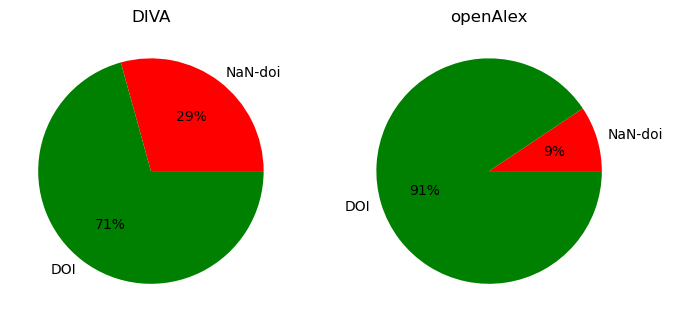

		 Total 	 NaN DOI
DIVA: 		 69841 	 20462 		 29.30%
openAlex: 	 46126 	 4329 		 9.39%
openAlex: 	 48867 	 4329 		 0.00%


In [5]:
## Count NaN Values of DOI
nan_count0= df0["DOI"].isna().sum()

## Count NaN Values of openAlex
nan_count1= df1["DOI"].isna().sum()


## Count NaN Values of dois_from_diva_in_alex
nan_count2= df2["DOI"].isna().sum()





fig = plt.figure(figsize=(8,6), dpi=100)
publisher_name="NaN values In DIVA v.s openAlex"

data0=[nan_count0,len(df0)-nan_count0]
ax1 = plt.subplot2grid((1,2),(0,0))
plt.pie(data0,
        labels =["NaN-doi","DOI"],
        autopct='%.0f%%',
        colors=["red","green"]
       )
plt.title("DIVA")


data1=[nan_count1,len(df1)-nan_count1]
ax2 = plt.subplot2grid((1,2),(0,1))
plt.pie(data1,
        labels =["NaN-doi","DOI"],
        autopct='%.0f%%',
        colors=["red","green"]
       )
plt.title("openAlex")
plt.show()

print("\t\t","Total","\t","NaN DOI")
print("DIVA:","\t\t",len(df0),"\t",nan_count0,"\t\t",f"{nan_count0/ len(df0) :.2%}") # 100*nan_count/len(df) 
print("openAlex:","\t",len(df1),"\t",nan_count1,"\t\t",f"{nan_count1/(len(df1)) :.2%}") # 100*nan_count/len(df)
print("openAlex:","\t",len(df2),"\t",nan_count1,"\t\t",f"{nan_count2/(len(df2)) :.2%}") # 100*nan_count/len(df)

In [6]:
print("all with NaN:",len(df0))
dois=df0["DOI"].dropna()
print("Without  NaN:",len(dois))

print("With no doublicates:",len((dois.drop_duplicates())))
dois.head()


all with NaN: 69841
Without  NaN: 49379
With no doublicates: 49378


1                  10.1186/2210-4690-2-4
2          10.1016/j.matchar.2018.03.024
5               10.1109/TWC.2020.2974950
6    10.1109/APUSNCURSINRSM.2019.8889079
7             10.1103/PhysRevD.97.032005
Name: DOI, dtype: object

In [7]:
df0=diva_data
# print(df0.columns)
print(df0.groupby("PublicationType").count().sort_values(by=["DOI"],ascending=False)["DOI"])
# df0.head()

print()
df1=openAlex_data
df1=df1.rename(columns={"work": "DOI"})
# print(df1.columns)
df2=dois_from_diva_in_alex
df2=df2.rename(columns={"work": "DOI"})

print(df1.groupby("type").count().sort_values(by=["DOI"],ascending=False)["DOI"])


PublicationType
Artikel i tidskrift                    36067
Konferensbidrag                        10877
Kapitel i bok, del av antologi          1356
Artikel, forskningsöversikt              770
Artikel, recension                        96
Bok                                       89
Samlingsverk (redaktörskap)               58
Proceedings (redaktörskap)                22
Rapport                                   21
Övrigt                                    13
Doktorsavhandling, sammanläggning          3
Dataset                                    3
Manuskript (preprint)                      2
Doktorsavhandling, monografi               2
Licentiatavhandling, monografi             0
Licentiatavhandling, sammanläggning        0
Patent                                     0
Konstnärlig output                         0
Name: DOI, dtype: int64

type
journal-article        30428
proceedings-article     7576
book-chapter            2397
posted-content          1067
proceedings               49

In [8]:
diva=pd.DataFrame(
    {
        "title":df0["Title"],
        "DOI":df0["DOI"]
    }
)

alex=pd.DataFrame(
    {
        "title":df1["title"],
        "DOI":[str(i).replace("https://doi.org/","") for i in df1["DOI"]]
    }
)


## delete "nan" in alex["DOI"]
alex=alex[alex["DOI"]!="nan"]


## finding number of  NaN values in title columns
print("Titles")
print("Diva with no title:",diva["title"].isna().sum())
print("openAlex with no title:",alex["title"].isna().sum())

print()

# ## finding number of  NaN values in DOI columns
print("DOIs")
print("Diva with no DOI:",diva["DOI"].isna().sum())
print("openAlex with no DOI:",alex["DOI"].isna().sum())
print("obs! the work in the OpenAlex  has id like ID W2741809807 then https://api.openalex.org/works/W2741809807 ")

print()

## finding number of duplicates and its percentage 
print("duplicate titles")
print("DIVA  duplicate:",f"{1-len(diva.drop_duplicates(ignore_index=True))/len(diva):.2%}")
print("openAlex duplicate:",f"{1-len(alex.drop_duplicates(ignore_index=True))/len(alex):.2%}")

print()

## Droping duplicates
diva=diva.drop_duplicates(ignore_index=True)
alex=alex.drop_duplicates(ignore_index=True)
####
###
## finding common titles in both DIVA & OpenAlex
# int_df0 = pd.merge(diva1,alex1, how ='inner', on =['title'])
# print("diva_titles: ",len(diva1),"---","diva_titles: ",len(alex1),"---","Intersection: ",len(int_df0), "-->",f"{len(int_df0)/len(diva1):.2%}")#,int_df )
# print()
## finding common DIO in both DIVA & OpenAlex
int_df = pd.merge(diva,alex, how ='inner', on =['DOI'])
print("diva_DOIs: ",len(diva),"---","openAlex_Dois: ",len(alex),"---","Intersection: ",len(int_df), "-->",f"{len(int_df)/len(diva):.2%}")#,int_df )

# [str(work).strip("https://doi.org/") for work in df1["work"]]
print()
print("NaN Values diva")
print(diva.isna().sum())
print()
print("NaN Values openalex")
print(alex.isna().sum())

Titles
Diva with no title: 0
openAlex with no title: 9

DOIs
Diva with no DOI: 20462
openAlex with no DOI: 0
obs! the work in the OpenAlex  has id like ID W2741809807 then https://api.openalex.org/works/W2741809807 

duplicate titles
DIVA  duplicate: 0.40%
openAlex duplicate: 0.01%

diva_DOIs:  69560 --- openAlex_Dois:  41793 --- Intersection:  25453 --> 36.59%

NaN Values diva
title        0
DOI      20182
dtype: int64

NaN Values openalex
title    9
DOI      0
dtype: int64


In [9]:
## Title-comparison 
print("Title-comparison")
print()
diva1=pd.DataFrame(diva["title"]).dropna()
alex1=pd.DataFrame(alex["title"]).dropna()

int_df3= pd.merge(diva1,alex1, how ='inner', on =['title'])
print("diva_titles: ",len(diva1))
print("openAlex_titles: ",len(alex1))
print("Intersection (i.e. similar titles): ",len(int_df), "-->",f"{len(int_df3)/len(diva1):.2%}")#,int_df )

# print(diva1.isna().sum())

Title-comparison

diva_titles:  69560
openAlex_titles:  41784
Intersection (i.e. similar titles):  25453 --> 31.91%


In [10]:
## Count NaN Values of DOI
nan_count0 = df0["DOI"].isna().sum()
nan_count1 = df1["DOI"].isna().sum()

print("NaN DOI")
print()
print("Diva,Count NaN Values:","\t",nan_count0,"\t",f"{nan_count0/ len(df0) :.2%}") # 100*nan_count/len(df) 
print("openAlex, Count NaN Values:","\t",nan_count1,"\t",f"{nan_count1/ len(df1) :.2%}") # 100*nan_count/len(df) 
df1["DOI"].isna().count()

NaN DOI

Diva,Count NaN Values: 	 20462 	 29.30%
openAlex, Count NaN Values: 	 4329 	 9.39%


46126

In [11]:
 pd.DataFrame(df0.isna().sum()),pd.DataFrame(df1.isna().sum())

(                            0
 PID                         0
 Name                       45
 Title                       0
 PublicationType             0
 ContentType                36
 ...                       ...
 ArticleId               59132
 Reviewed                    0
 FreeFulltext            60689
 SustainableDevelopment  69841
 Contributor             69670
 
 [68 rows x 1 columns],
                       0
 title                 9
 DOI                4329
 First_author          1
 institution           0
 is OA                 0
 color_OA           4517
 host_name          1468
 publisher         10528
 publication_year      0
 type               1590
 issn              14122)

PublicationType
Artikel i tidskrift                    39053
Artikel, forskningsöversikt              804
Artikel, recension                       229
Bok                                      315
Dataset                                   36
Doktorsavhandling, monografi             474
Doktorsavhandling, sammanläggning       2925
Kapitel i bok, del av antologi          2685
Konferensbidrag                        19325
Konstnärlig output                        36
Licentiatavhandling, monografi           246
Licentiatavhandling, sammanläggning      981
Manuskript (preprint)                    170
Patent                                   170
Proceedings (redaktörskap)                98
Rapport                                 1708
Samlingsverk (redaktörskap)              180
Övrigt                                   406
dtype: int64

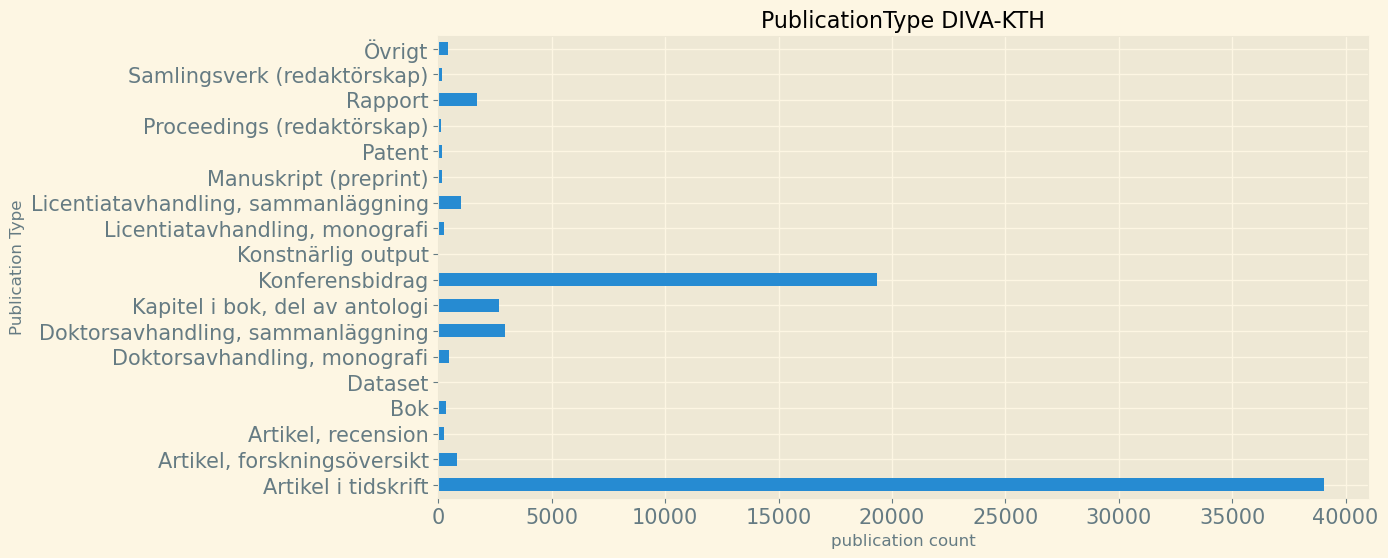

In [12]:
plt.style.use('Solarize_Light2')
df00=df0[["Title","PublicationType"]]

df00.groupby("PublicationType").count().plot.barh(title="PublicationType DIVA-KTH",xlabel="publication count",ylabel="Publication Type",figsize=(12,6),fontsize=15,legend=False)
display(df00.groupby(by=["PublicationType"]).size())

type
book                      73
book-chapter            2406
component                  1
dataset                   13
dissertation               8
journal-article        30711
journal-issue              2
monograph                 12
other                     38
peer-review               30
posted-content          2595
proceedings               53
proceedings-article     8498
reference-book             1
reference-entry           40
report                    48
report-series              2
type                       5
dtype: int64

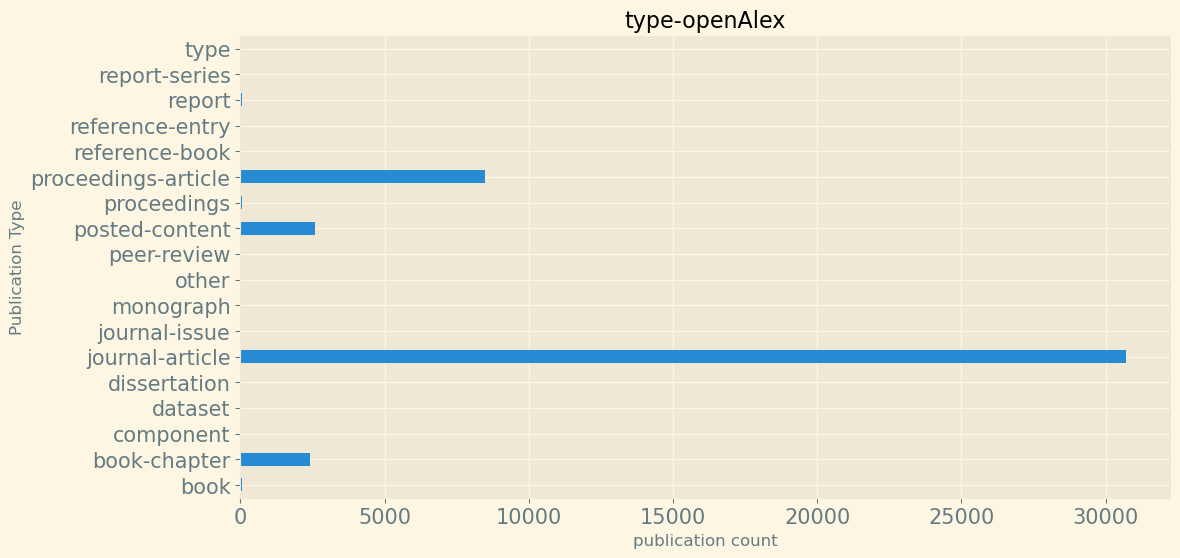

In [13]:
plt.style.use('Solarize_Light2')
df11=df1[["title","type"]]

df11.groupby("type").count().plot.barh(title="type-openAlex",xlabel="publication count",ylabel="Publication Type",figsize=(12,6),fontsize=15,legend=False)
df11.groupby("type").size()

#### Journal_article DIVA vs openAlex

Journal_article DIVA vs openAlex

DIVA-journal article: 36066 
openAlex-journal article:  30426 
Intersection: 26721 ----> 74.09%

KTH dois in openAlex and not in DIVA: 3705


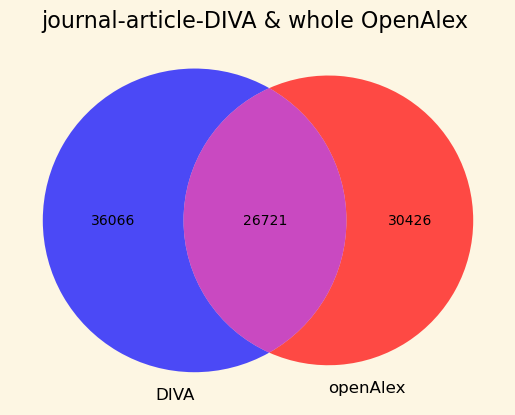

,0
8,10.3182/20140824-6-za-1003.01262
11,10.1002/adma.202210713
14,10.1021/cr900356p
31,10.1051/epjconf/202023701009
41,10.1007/s43684-021-00009-9
...,...
30368,10.4028/www.scientific.net/msf.858.978
30391,10.1021/acs.chemmater.2c02447
30400,10.1021/acs.chemrev.7b00060
30406,10.1007/s00603-022-02913-9


In [14]:
## Comparison Diva and openAlex  by journal_article
print("Journal_article DIVA vs openAlex")
print()

diva_journal_article=df0[df0["PublicationType"]=="Artikel i tidskrift"]


## "Artikel i tidskrift" or "Konferensbidrag"
# diva_journal_article=df0.loc[
#     (df0["PublicationType"]=="Artikel i tidskrift")|
    # (df0["PublicationType"]=="Konferensbidrag") #|
    # (df0["PublicationType"]=="Licentiatavhandling, sammanläggning")#|
#     # (df0["PublicationType"]=="Doktorsavhandling, sammanläggning")|
#     # (df0["PublicationType"]=="Kapitel i bok, del av antologi")|
#     # (df0["PublicationType"]=="Rapport")
# ]
# ##
diva=diva_journal_article["DOI"].dropna()

openalex_journal_article=df1[df1["type"]=="journal-article"]#
alex=openalex_journal_article["DOI"].dropna()

### "https://doi.org/10.1021/cr900356p".replace("https://doi.org/","")# in set(alex)

diva=[doi.lower() for doi in set(diva)]
alex=[doi.replace("https://doi.org/","").lower() for doi in set(alex)]
# "10.1021/cr900356p" in alex
alex=pd.DataFrame(alex)
diva=pd.DataFrame(diva)




### finding common titles in both DIVA & OpenAlex
int_df = pd.merge(diva,alex, how ="inner", on =[0])
print("DIVA-journal article:",len(diva),"\nopenAlex-journal article: ",len(alex),"\nIntersection:",len(int_df), "---->",f"{len(int_df)/len(diva):.2%}")#,int_df )
print()
print("KTH dois in openAlex and not in DIVA:",len(alex)-len(int_df))
diva.head(),alex.head()


from matplotlib_venn import venn2, venn2_circles# depict venn diagram
venn2(subsets = (len(diva)
                 ,len(alex), len(int_df)),
      set_labels = ('DIVA', 
                    'openAlex'),
      set_colors=("blue",
                  "red",
                 ),alpha=0.7)
# assign title of the venn diagram
plt.title("journal-article-DIVA & whole OpenAlex ")  
plt.show()



## Konferensbidrag
alex_doi_not_diva=pd.DataFrame(pd.concat([alex,int_df]).drop_duplicates(keep=False)[0])#.isna().sum()#.reset_index()

# pd.DataFrame(pd.concat([diva,alex_doi_not_diva]).drop_duplicates(keep=False)["DOI"])#.isna().sum()#.reset_index()

alex_doi_not_diva
# diva_journal_article[["PublicationType","DOI"]]
# alex_doi_not_diva.to_csv("journal_articles_alex_doi_not_diva.csv",index=False)

In [15]:
## random 50 articles 
dois=alex_doi_not_diva[0][random.sample(list(alex_doi_not_diva.index),50)]
pipe_separated_dois = "|".join(dois.values)
r = requests.get(f"https://api.openalex.org/works?filter=doi:{pipe_separated_dois}")
works = r.json()["results"]
for work in works:
    print(work["doi"],"---",work["display_name"],"---",work["type"])

https://doi.org/10.1039/c8cs00897c --- Artificial photosynthesis: opportunities and challenges of molecular catalysts --- journal-article
https://doi.org/10.1016/j.jbiomech.2011.11.021 --- Mechanics, mechanobiology, and modeling of human abdominal aorta and aneurysms --- journal-article
https://doi.org/10.1016/j.rser.2017.01.108 --- Phase equilibrium in the design of phase change materials for thermal energy storage: State-of-the-art --- journal-article
https://doi.org/10.1016/j.isci.2020.101303 --- Current Status of COVID-19 Therapies and Drug Repositioning Applications --- journal-article
https://doi.org/10.5006/2458 --- A Critical Review on Corrosion and Runoff from Zinc and Zinc-Based Alloys in Atmospheric Environments --- journal-article
https://doi.org/10.1016/j.procir.2018.03.224 --- Deep Learning-based Multimodal Control Interface for Human-Robot Collaboration --- journal-article
https://doi.org/10.1016/j.procir.2016.01.196 --- Predicting Chemical Wear in Machining Titanium All

In [16]:
import requests

dois = ["10.3322/caac.21660", "https://doi.org/10.1136/bmj.n71", "10.3322/caac.21654"]
pipe_separated_dois = "|".join(dois)
r = requests.get(f"https://api.openalex.org/works?filter=doi:{pipe_separated_dois}&per-page=50&mailto=support@openalex.org")
works = r.json()["results"]

for work in works:
    print(work["doi"], work["display_name"])

# # results
# https://doi.org/10.3322/caac.21660 Global Cancer Statistics 2020: GLOBOCAN Estimates of Incidence and Mortality Worldwide for 36 Cancers in 185 Countries
# https://doi.org/10.1136/bmj.n71 The PRISMA 2020 statement: an updated guideline for reporting systematic reviews
# https://doi.org/10.3322/caac.21654 Cancer Statistics, 2021


https://doi.org/10.3322/caac.21660 Global Cancer Statistics 2020: GLOBOCAN Estimates of Incidence and Mortality Worldwide for 36 Cancers in 185 Countries
https://doi.org/10.1136/bmj.n71 The PRISMA 2020 statement: an updated guideline for reporting systematic reviews
https://doi.org/10.3322/caac.21654 Cancer Statistics, 2021


In [17]:
doi=["10.4028/www.scientific.net/msf.717-720.221"
    ,"10.21428/bf6fb269.824814be",
     "10.1016/j.nucengdes.2022.111876"]
r=requests.get("https://api.openalex.org/works/https://doi.org/" + doi[0]).json()
r["type"]#["host_venue"]

'journal-article'

- 10.21428/bf6fb269.824814be  ---- journal-article in openAlex ,Konferensbidarg in DIVA

In [254]:
# df0.loc[(df0["PublicationType"]=="Artikel i tidskrift") | (df0["PublicationType"]=="Konferensbidrag")]

In [ ]:
# "10.21428/bf6fb269.824814be" 
doi[1] in set(diva[0])

False

__It means some of DOI's are konferensbidrag in DIVA and journal-article in openAlex__

In [43]:
## finding DOI's
boolean=[doi in set(diva[0]) for doi in alex_doi_not_diva[0]] ## boolean for element  konferensbidrag and in openalex [true,false.....]
DOIs=alex_doi_not_diva[[doi in set(diva[0]) for doi in alex_doi_not_diva[0]]]
# [doi  for doi in alex_doi_not_diva[0]]

DOIs


,0


In [18]:
boolean=[doi in set(diva[0]) for doi in alex_doi_not_diva[0]] ## boolean for element  konferensbidrag and in openalex [true,false.....]
## only dois not diva conferenc bidar and articlels
alex_doi_not_diva[[not x for x in boolean]] ## negating the boolean 

,0
8,10.3182/20140824-6-za-1003.01262
11,10.1002/adma.202210713
14,10.1021/cr900356p
31,10.1051/epjconf/202023701009
41,10.1007/s43684-021-00009-9
...,...
30368,10.4028/www.scientific.net/msf.858.978
30391,10.1021/acs.chemmater.2c02447
30400,10.1021/acs.chemrev.7b00060
30406,10.1007/s00603-022-02913-9


In [30]:
doi="10.4028/www.scientific.net/msf.858.978"#"10.1021/acs.chemrev.7b00060" 
print([doi in set(df0["DOI"])])
df0[df0["DOI"]==doi]["PublicationType"]


[False]


Series([], Name: PublicationType, dtype: object)

#### Konferensbidrag

19325
DIVA,Konferensbidrag: 10877 
openAlex, DOI's:  41790 
Intersection: 8338 ----> 76.66%



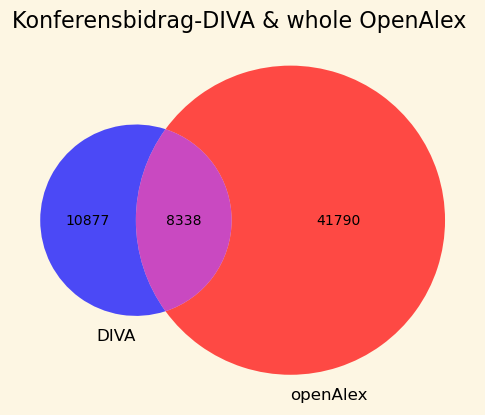

,0
0,10.1109/apemc.2010.5475661
1,10.1109/ptc.2015.7232725
2,10.1007/978-3-642-54734-8_9
3,10.1364/cleo_at.2020.jtu2f.16
4,10.1007/978-3-319-57934-4_8
...,...
8333,10.1109/isci.2011.5958924
8334,10.23919/ecc.2018.8550247
8335,10.1109/isap.2011.6082181
8336,10.1109/cdc.2010.5718109


In [31]:
## Comparison Diva and openAlex  by journal_article

diva_Konferensbidrag=df0[df0["PublicationType"]=="Konferensbidrag"]
print(len(diva_Konferensbidrag))
diva=diva_Konferensbidrag["DOI"].dropna()

openalex_journal_article=df1[["type","DOI"]]
alex=openalex_journal_article["DOI"].dropna()

### "https://doi.org/10.1021/cr900356p".replace("https://doi.org/","")# in set(alex)

diva=[doi.lower() for doi in set(diva)]
alex=[doi.replace("https://doi.org/","").lower() for doi in set(alex)]
# "10.1021/cr900356p" in alex
alex=pd.DataFrame(alex)
diva=pd.DataFrame(diva)




### finding common titles in both DIVA & OpenAlex
int_df = pd.merge(diva,alex, how ="inner", on =[0])
print("DIVA,Konferensbidrag:",len(diva),"\nopenAlex, DOI's: ",len(alex),"\nIntersection:",len(int_df), "---->",f"{len(int_df)/len(diva):.2%}")#,int_df )
print()

diva.head(),alex.head()



venn2(subsets = (len(diva)
                 ,len(alex), len(int_df)),
      set_labels = ('DIVA', 
                    'openAlex'),
      set_colors=("blue",
                  "red",
                 ),alpha=0.7)
# assign title of the venn diagram
plt.title("Konferensbidrag-DIVA & whole OpenAlex ")  
plt.show()
int_df

#### all DOI

DIVA,journal article: 49378 
openAlex, journal article:  41790 
Intersection: 36564 ----> 74.05%

KTH dois in openAlex and not in DIVA: 5226


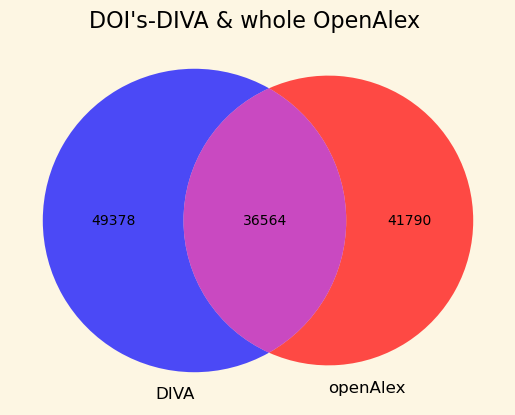


title: Exploring the Prototypical Definitions of Intelligent Engineers Held by Irish and Swedish Higher Education Engineering Students 
 doi: https://doi.org/10.1177/00332941211000667 
 type: journal-article 
 [{'id': 'https://openalex.org/I86987016', 'display_name': 'Royal Institute of Technology', 'ror': 'https://ror.org/026vcq606', 'country_code': 'SE', 'type': 'education'}]


,0
5,10.1109/icocn.2014.6987103
6,10.23919/cnsm55787.2022.9965060
15,10.1002/adma.202210713
30,10.48550/arxiv.1704.03054
33,10.1017/cbo9781139032681.011
...,...
41776,10.1109/bigdata55660.2022.10020988
41785,10.5281/zenodo.7561142
41787,10.1109/gcwkshps56602.2022.10008580
41788,10.2749/vancouver.2017.0336


In [32]:
## ALL

diva_type_doi=df0[["PublicationType","DOI"]]
diva=diva_type_doi["DOI"].dropna()

openalex_type_doi=df1[["type","DOI"]]
alex=openalex_type_doi["DOI"].dropna()

### "https://doi.org/10.1021/cr900356p".replace("https://doi.org/","")# in set(alex)

diva=[doi.lower() for doi in set(diva)]
alex=[doi.replace("https://doi.org/","").lower() for doi in set(alex)]
# "10.1021/cr900356p" in alex
alex=pd.DataFrame(alex)
diva=pd.DataFrame(diva)




### finding common titles in both DIVA & OpenAlex
int_df = pd.merge(diva,alex, how ="inner", on =[0])
print("DIVA,journal article:",len(diva),"\nopenAlex, journal article: ",len(alex),"\nIntersection:",len(int_df), "---->",f"{len(int_df)/len(diva):.2%}")
print()
print("KTH dois in openAlex and not in DIVA:",len(alex)-len(int_df))
diva.head(),alex.head()



venn2(subsets = (len(diva)
                 ,len(alex), len(int_df)),
      set_labels = ('DIVA', 
                    'openAlex'),
      set_colors=("blue",
                  "red",
                 ),alpha=0.7)

# assign title of the venn diagram
plt.title("DOI's-DIVA & whole OpenAlex ")  
plt.show()
alex_doi_not_diva=pd.DataFrame(pd.concat([alex,int_df]).drop_duplicates(keep=False)[0])#.isna().sum()#.reset_index()



doi="10.1177/00332941211000667"#,"10.1007/978-3-030-18488-9_74"#,"10.1117/12.2507210"#,"10.1109/ipdpsw55747.2022.00107"
#doi="10.1016/j.compscitech.2019.05.025" # Corrigendum to "/10.1016/j.compscitech.2017.09.009"


print()
result = requests.get("https://api.openalex.org/works/https://doi.org/" + f"{doi}").json()
print("title:",result["title"],"\n","doi:",result["doi"],"\n","type:",result["type"],"\n",result["authorships"][0]["institutions"])


alex_doi_not_diva

In [65]:
dois=alex_doi_not_diva[0][random.sample(list(alex_doi_not_diva.index),10)]
["110.1016/j.matchar.2018.03.024"  in (df0["DOI"])]
# doi="10.4028/www.scientific.net/msf.858.978"#"10.1021/acs.chemrev.7b00060" 
# print([doi in set(df0["DOI"])])
# df0[df0["DOI"]==doi]["PublicationType"]
for doi in dois:
    doi=str(doi)
    print(doi)
    print([doi in set(df0["DOI"])],df0[df0["DOI"]==doi]["PublicationType"])
    
print()
["10.1021/acs.chemrev.7b00060" in set(df0["DOI"])],["110.1016/j.matchar.2018.03.024"  in (df0["DOI"])]

10.1073/pnas.2210669119
[False] Series([], Name: PublicationType, dtype: object)
10.1101/350512
[False] Series([], Name: PublicationType, dtype: object)
10.1007/978-3-319-06653-0_3
[False] Series([], Name: PublicationType, dtype: object)
10.1109/icops35962.2018.9575376
[False] Series([], Name: PublicationType, dtype: object)
10.1007/978-3-319-38889-2_54-1
[False] Series([], Name: PublicationType, dtype: object)
10.1002/adma.202201470
[False] Series([], Name: PublicationType, dtype: object)
10.1101/2020.07.06.186601
[False] Series([], Name: PublicationType, dtype: object)
10.12688/f1000research.16083.2
[False] Series([], Name: PublicationType, dtype: object)
10.3390/applnano2030014
[False] Series([], Name: PublicationType, dtype: object)
10.1039/d1nr08255h
[False] Series([], Name: PublicationType, dtype: object)



([True], [False])

#### getting works-kth from openALex by institutions.id:I86987016 kth

In [71]:
##all doi in openalex
## f"https://api.openalex.org/works?per-page=200&page={page}&filter=institutions.id:I86987016,from_publication_date:{start},to_publication_date:{end}"
# start="2010-01-01"
# end="2023-02-24"
# page=1
# r=requests.get(f"https://api.openalex.org/works?per-page=200&page={page}&filter=institutions.id:I86987016,from_publication_date:{start},to_publication_date:{end}").json()


# for page in range(1,r["meta"]["count"]//200+2):

    
#     ### ALL
#     url=f"https://api.openalex.org/works?per-page=200&page={page}&filter=institutions.id:I86987016,from_publication_date:{start},to_publication_date:{end}"
    

#     response = requests.get(url)
#     r=response.json()

#     for i  in range(len(r["results"])):
#         work=r["results"][i]["doi"]
#         title=r["results"][i]["title"]
#         publication_year=r["results"][i]["publication_year"]
        
#         First_author=r["results"][i]["authorships"][0]["author"]["display_name"]
#         if r["results"][i]["authorships"][0]["institutions"]!=[]:
#             institution=r["results"][i]["authorships"][0]["institutions"][0]["display_name"]
#         else:
#                 institution="--"
#         is_OA=r["results"][i]["open_access"]["is_oa"]
#         color_OA=r["results"][i]["open_access"]["oa_status"]
#         host_name=r["results"][i]["host_venue"]["display_name"]
#         publisher_name=r["results"][i]["host_venue"]["publisher"]
#         WorkType=r["results"][i]["type"]
#         journalISSN=r["results"][i]["host_venue"]["issn"]
    
#         ## appending results
#         titles.append(title)
#         works.append(work)
#         First_authors.append(First_author)
#         institutions.append(institution)
#         is_OA_list.append(is_OA)
#         color_OA_list.append(color_OA)
#         host_name_list.append(host_name)
        # publishers_list.append(publisher_name)
        # year.append(publication_year)

In [261]:
# print("10.1021/cr900356p" in DOI_ALEX)
# print('10.1016/j.matchar.2018.03.024' in DOI_ALEX)
# print('10.1140/epjc/s10052-020-7624-4' in DOI_ALEX)

# print()
# print('10.1021/cr900356p' in DOI_ALEX)
# print('10.1021/cr900356p' in  set(diva["DOI"]))
# print('10.1021/cr900356p' in  set(alex["DOI"]))

# print()
# print('10.1021/bm101302t' in DOI_ALEX)
# print('10.1021/bm101302t' in  set(diva["DOI"]))
# print('10.1021/bm101302t' in  set(alex["DOI"]))

# print()
# print('10.2139/ssrn.4329484' in DOI_ALEX)
# print('10.2139/ssrn.4329484' in  set(diva["DOI"]))
# print('10.2139/ssrn.4329484' in  set(alex["DOI"]))



#### Plot  host name publisher-openAlex

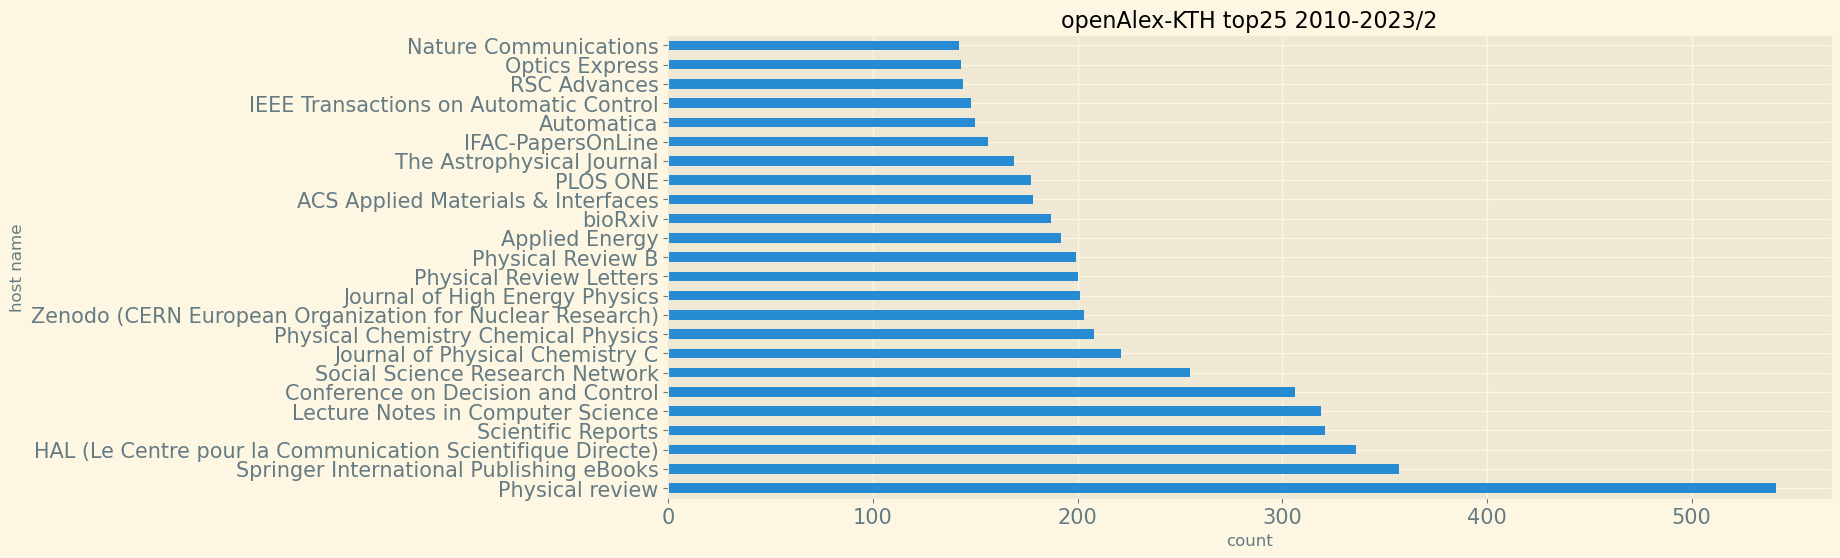

In [48]:
plt.style.use('Solarize_Light2')

openAlex_host=df1[["title","host_name"]]

openAlex_host.groupby("host_name").count().sort_values(by=["title"],ascending=False)[1:25].plot.barh(title="openAlex-KTH top25 2010-2023/2",xlabel="count",ylabel="host name",figsize=(15,6),fontsize=15,legend=False)
plt.show()
# openAlex_host.groupby("host_name").count().sort_values(by=["title"],ascending=False)[1:25]

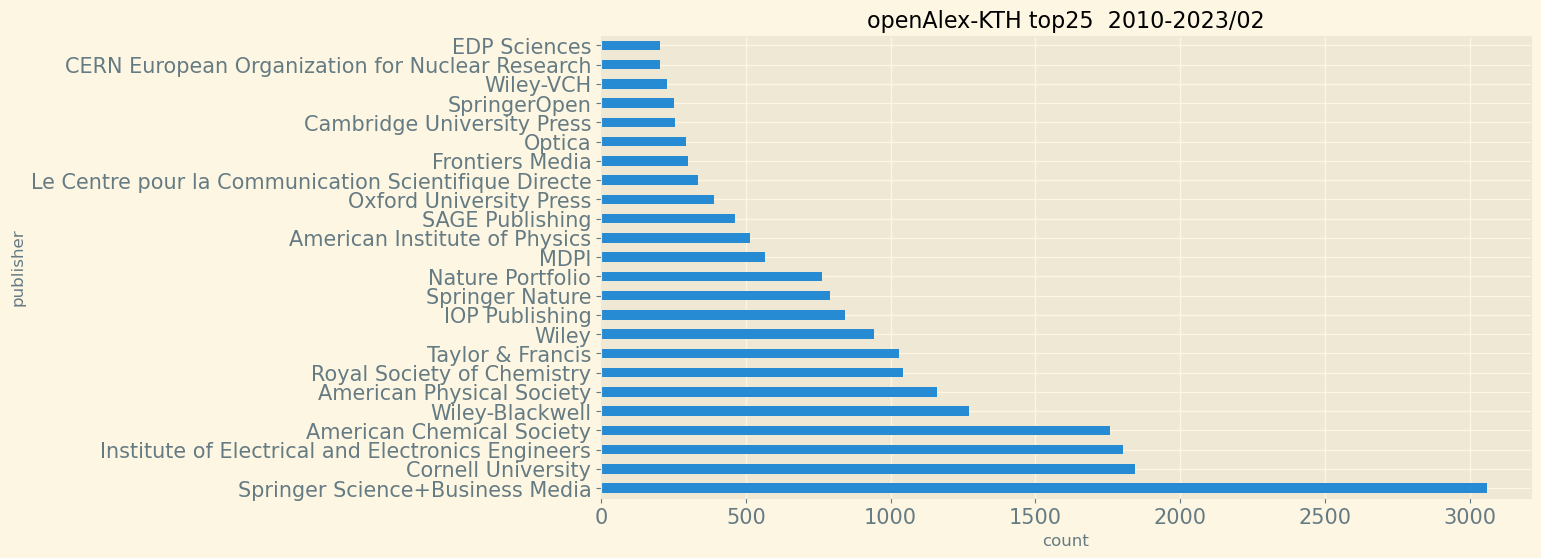

In [49]:
plt.style.use('Solarize_Light2')

openAlex_publisher=df1[["title","publisher"]]

openAlex_publisher.groupby("publisher").count().sort_values(by=["title"],ascending=False)[1:25].plot.barh(title="openAlex-KTH top25  2010-2023/02",xlabel="count",ylabel="publisher",figsize=(12,6),fontsize=15,legend=False)
plt.show()
# openAlex_publisher.groupby("publisher").count().sort_values(by=["title"],ascending=False)[1:25]

In [63]:
diva_doi=df0["DOI"]
alex_doi=[str(doi).replace("https://doi.org/","") for doi in df1["DOI"]]
# [doi for doi in ]
len([doi for doi in alex_doi if  doi not in set(diva_doi)])

20673